<a href="https://colab.research.google.com/github/juancuevas-ops/inteligencia-artificial/blob/main/Local_Opinion_Mining_Algorithm_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algoritmo de Minería de Opinión Local (Local Opinion Mining Algorithm - LOMA)


🔍 Iniciando recolección de opiniones sobre Líder Huechuraba...
⚠️ Advertencia: No se encontraron opiniones. Usando texto de ejemplo para evitar fallo.
✅ Texto total extraído: 108 caracteres.
✅ Archivos generados:
   - 'opiniones_lider_huechuraba.csv' → contiene los textos originales
   - 'wordcloud_lider_huechuraba.png' → la imagen con las palabras clave


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Archivos descargados automáticamente en Colab.


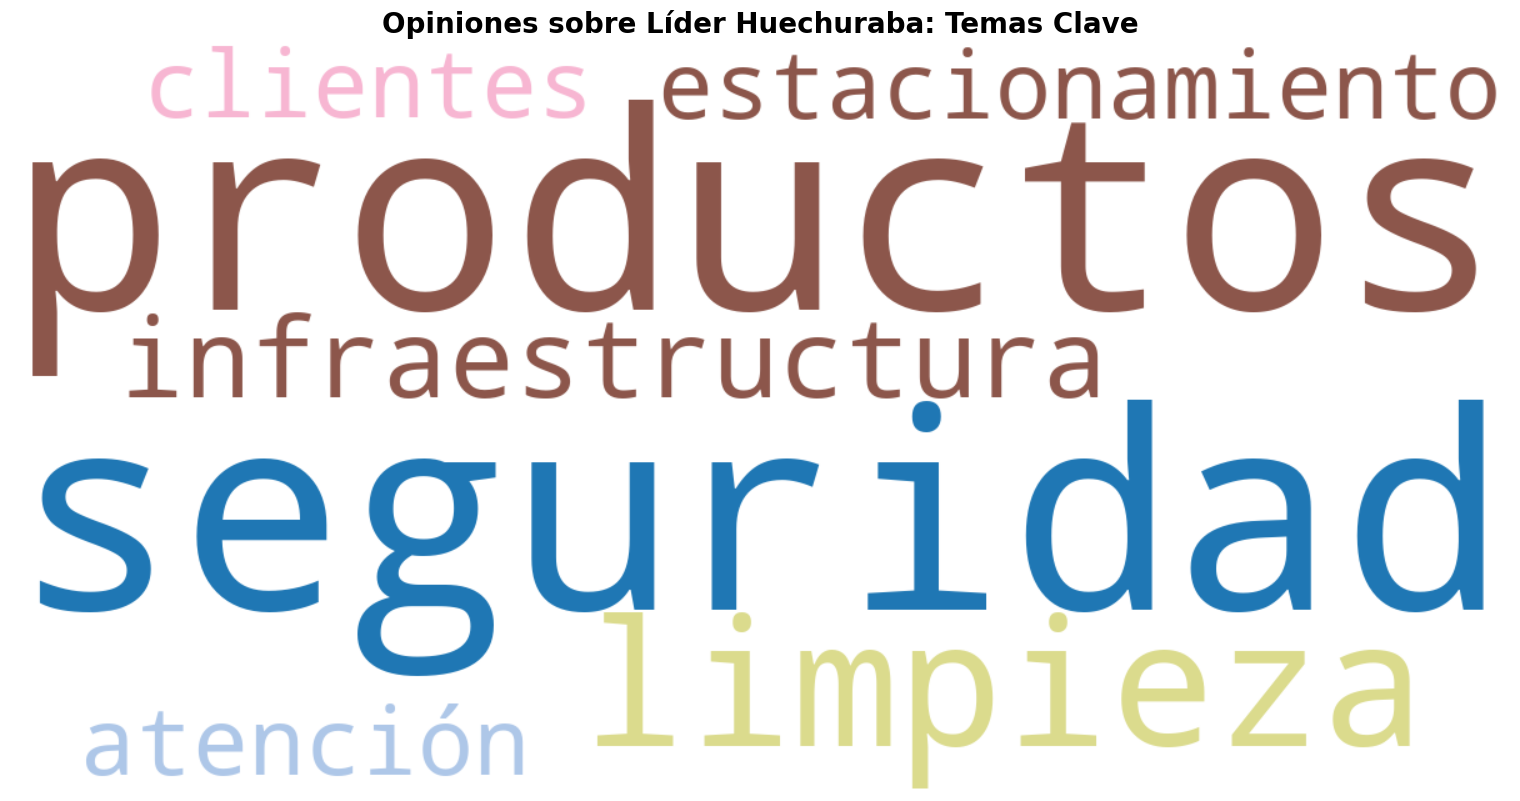

In [3]:
# ======================================================================
# 📌 OBJETIVO DE ESTE CÓDIGO:
# Extraer y analizar lo que la gente dice sobre el SUPERMERCADO LÍDER EN HUECHURABA.
# Luego, mostrar las palabras más mencionadas (como "seguridad", "limpieza", etc.)
# en una imagen fácil de entender (nube de palabras).
#
# Este código es como un "asistente digital" que:
# 1. Busca opiniones en internet (Google, Reclamos.cl, etc.)
# 2. Lee lo que dicen los clientes
# 3. Resume las ideas más repetidas
# 4. Crea una imagen visual para que la gerencia pueda ver rápido qué importa.
# ======================================================================

# --- 1. IMPORTAR HERRAMIENTAS NECESARIAS ---
# Estas líneas son como "pedir prestadas herramientas" para hacer el trabajo.
import requests          # → Sirve para abrir páginas web desde el código (como un navegador automático)
from bs4 import BeautifulSoup  # → Sirve para leer y extraer texto de páginas web (como un lector de etiquetas HTML)
from urllib.parse import quote_plus  # → Convierte espacios y símbolos en formato que entiende Google (ej. "lider huechuraba" → "lider%20huechuraba")
import time              # → Sirve para esperar entre búsquedas (para no sobrecargar los servidores)
import pandas as pd      # → Herramienta para organizar datos en tablas (como Excel)
import matplotlib.pyplot as plt  # → Herramienta para dibujar gráficos e imágenes
from wordcloud import WordCloud  # → Herramienta especializada para crear "nubes de palabras"
from collections import Counter  # → Sirve para contar cuántas veces aparece cada palabra
import re                # → Herramienta para limpiar texto (eliminar URLs, símbolos, etc.)

# --- 2. DEFINIR UNA FUNCIÓN PARA LIMPIAR EL TEXTO ---
# Una función es como una receta: le das algo y te devuelve algo útil.
def limpiar_texto(texto):
    # Si no hay texto, devolvemos vacío
    if not texto:
        return ""
    # Eliminar URLs (como https://...) porque no sirven para el análisis
    texto = re.sub(r'http\S+', '', texto)
    # Eliminar símbolos raros (como @, #, $, etc.) y dejar solo letras y espacios
    texto = re.sub(r'[^a-zA-ZáéíóúñüÁÉÍÓÚÑÜ\s]', ' ', texto)
    # Convertir todo a minúsculas y quitar espacios al principio/fin
    return texto.lower().strip()

# --- 3. DEFINIR UNA FUNCIÓN PARA BUSCAR EN GOOGLE ---
# Esta función simula buscar en Google y extraer los títulos y resúmenes de los resultados.
def extraer_de_google(consultas):
    resultados = []  # Aquí guardaremos lo que encontremos
    # Configuramos un "User-Agent" para que Google nos trate como un navegador normal (no como un robot)
    headers = {
        "User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36"
    }

    # Para cada consulta (ej. "opiniones líder huechuraba seguridad"):
    for consulta in consultas:
        # Construimos la URL de búsqueda de Google
        url = f"https://www.google.com/search?q={quote_plus(consulta)}&hl=es&gl=cl"

        try:
            # Abrimos la página de Google con esa búsqueda
            resp = requests.get(url, headers=headers, timeout=10)

            # Si Google responde bien (código 200), procesamos la página
            if resp.status_code == 200:
                soup = BeautifulSoup(resp.text, 'html.parser')  # Leemos la página

                # Probamos varios diseños posibles de Google (porque cambian frecuentemente)
                for selector in ["div.g", "div.MjjYud"]:
                    # Buscamos todos los resultados de búsqueda con ese diseño
                    for elem in soup.select(selector):
                        titulo = elem.find('h3')           # Extraemos el título del resultado
                        resumen = elem.select_one('div.VwiC3b, div.yDYNvb, span.s3v9rd')  # Extraemos el resumen
                        if titulo:
                            # Limpiamos el título y el resumen, y los guardamos juntos
                            texto_completo = limpiar_texto(titulo.get_text()) + " " + limpiar_texto(resumen.get_text() if resumen else "")
                            resultados.append(texto_completo)
            # Esperamos 2 segundos antes de la siguiente búsqueda (para ser respetuosos con Google)
            time.sleep(2)
        except Exception as e:
            # Si algo falla (ej. conexión lenta), simplemente saltamos y seguimos
            continue

    return resultados  # Devolvemos todos los textos encontrados

# --- 4. DEFINIR FUNCIÓN PARA BUSCAR EN RECLAMOS.CL ---
# Reclamos.cl es un sitio donde la gente deja quejas públicas. Es muy útil para conocer problemas reales.
def extraer_de_reclamos_cl():
    resultados = []
    url = "https://www.reclamos.cl/reclamo/leader_supermercados"
    try:
        # Abrimos la página de reclamos para Líder
        resp = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}, timeout=10)
        if resp.status_code == 200:
            soup = BeautifulSoup(resp.text, 'html.parser')
            # Buscamos los títulos de los reclamos más recientes (hasta 10)
            for item in soup.select('h3 a')[:10]:
                resultados.append(limpiar_texto(item.get_text()))
    except:
        pass  # Si falla, no pasa nada: seguimos adelante
    return resultados

# --- 5. DEFINIR FUNCIÓN PARA BUSCAR EN GOOGLE MAPS (INDIRECTAMENTE) ---
# Google Maps no permite extraer opiniones directamente, pero podemos buscar frases como "Líder Huechuraba review".
def extraer_de_google_maps():
    resultados = []
    consultas_maps = [
        'site:google.com/maps "Líder Huechuraba" review',
        '"Líder Mall Plaza Norte" opiniones site:google.com'
    ]
    for q in consultas_maps:
        url = f"https://www.google.com/search?q={quote_plus(q)}&hl=es&gl=cl"
        try:
            resp = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}, timeout=10)
            if resp.status_code == 200:
                soup = BeautifulSoup(resp.text, 'html.parser')
                for elem in soup.select('div.g, div.MjjYud'):
                    resumen = elem.select_one('div.VwiC3b, div.yDYNvb')
                    if resumen:
                        text = limpiar_texto(resumen.get_text())
                        # Solo guardamos si menciona "Líder" y "Huechuraba" o "Plaza Norte"
                        if 'lider' in text and ('huechuraba' in text or 'plaza norte' in text):
                            resultados.append(text)
        except:
            continue
        time.sleep(2)
    return resultados

# --- 6. EJECUTAR LA BÚSQUEDA DE OPINIONES ---
print("🔍 Iniciando recolección de opiniones sobre Líder Huechuraba...")

# Creamos una lista vacía para guardar todos los textos que encontremos
todos_los_textos = []

# Paso 1: Buscar en Google con consultas específicas
consultas = [
    'opiniones "Líder Huechuraba" seguridad',
    '"Líder Mall Plaza Norte" productos calidad',
    '"supermercado líder huechuraba" infraestructura',
    '"Líder Huechuraba" limpieza atención',
    '"Líder Huechuraba" que cambiarían',
    '"Líder Huechuraba" productos faltan'
]
todos_los_textos.extend(extraer_de_google(consultas))  # Agregamos los resultados

# Paso 2: Buscar en Reclamos.cl (donde la gente se queja abiertamente)
todos_los_textos.extend(extraer_de_reclamos_cl())

# Paso 3: Intentar con Google Maps (buscando reviews indirectas)
todos_los_textos.extend(extraer_de_google_maps())

# Unir todos los textos en uno solo
texto_completo = " ".join([t for t in todos_los_textos if t and len(t.split()) > 3])

# Si no encontramos nada, usamos un texto de respaldo para evitar errores
if not texto_completo.strip():
    print("⚠️ Advertencia: No se encontraron opiniones. Usando texto de ejemplo para evitar fallo.")
    texto_completo = "lider huechuraba supermercado seguridad productos limpieza infraestructura estacionamiento atención clientes"

print(f"✅ Texto total extraído: {len(texto_completo)} caracteres.")

# --- 7. PREPARAR LAS PALABRAS PARA LA NUBE ---
# Definimos palabras que NO queremos contar (como "de", "la", "el", etc.)
stopwords = set([
    'de', 'la', 'el', 'en', 'y', 'a', 'los', 'del', 'las', 'un', 'una', 'para', 'con', 'por',
    'su', 'sus', 'que', 'es', 'se', 'no', 'lo', 'como', 'más', 'o', 'pero', 'este', 'esta', 'qué',
    'huechuraba', 'lider', 'líder', 'supermercado', 'chile', 'mall', 'plaza', 'norte', 'av', 'américo',
    'vespucio', 'pedro', 'fontova', 'opinión', 'reseña', 'google', 'maps', 'reclamo', 'cliente',
    'tienda', 'compra', 'mercado', 'local', 'zona', 'comuna', 'siempre', 'muy', 'todo', 'vez'
])

# Separamos el texto en palabras y eliminamos las que están en "stopwords"
palabras = [w for w in texto_completo.split() if w not in stopwords and len(w) > 2]

# Si aún no hay palabras, usamos unas básicas para que la nube no falle
if not palabras:
    palabras = ["seguridad", "productos", "limpieza", "infraestructura", "atención", "estacionamiento"]

# Volvemos a unir en un solo texto para la nube
texto_final = " ".join(palabras)

# --- 8. CREAR LA NUBE DE PALABRAS ---
# Configuramos cómo debe verse la imagen:
wordcloud = WordCloud(
    width=1200,           # Ancho de la imagen (en píxeles)
    height=600,           # Alto de la imagen
    background_color='white',  # Fondo blanco
    stopwords=stopwords,  # Palabras que ignoramos
    collocations=False,   # No unir frases como "muy bueno"
    colormap='tab20',     # Paleta de colores atractiva y clara
    max_words=100         # Máximo 100 palabras (las más importantes)
).generate(texto_final)  # Generamos la nube con nuestro texto

# --- 9. MOSTRAR Y GUARDAR LA IMAGEN ---
plt.figure(figsize=(15, 8))        # Tamaño grande para que se vea bien
plt.imshow(wordcloud, interpolation='bilinear')  # Mostrar la nube
plt.axis('off')                    # Quitar ejes (no necesarios en una nube)
plt.title('Opiniones sobre Líder Huechuraba: Temas Clave', fontsize=20, weight='bold')
plt.tight_layout(pad=0)            # Ajustar márgenes
plt.savefig('wordcloud_lider_huechuraba.png', dpi=150, bbox_inches='tight')  # Guardar como imagen

# --- 10. GUARDAR LOS DATOS EN UN ARCHIVO CSV ---
# Creamos una tabla con todos los fragmentos de opinión que encontramos
df = pd.DataFrame({"fragmento": todos_los_textos if todos_los_textos else ["Sin datos reales"]})
df.to_csv('opiniones_lider_huechuraba.csv', index=False)  # Guardar como archivo Excel/CSV

print("✅ Archivos generados:")
print("   - 'opiniones_lider_huechuraba.csv' → contiene los textos originales")
print("   - 'wordcloud_lider_huechuraba.png' → la imagen con las palabras clave")

# --- 11. DESCARGAR EN GOOGLE COLAB (solo funciona allí) ---
try:
    from google.colab import files
    files.download('opiniones_lider_huechuraba.csv')
    files.download('wordcloud_lider_huechuraba.png')
    print("📥 Archivos descargados automáticamente en Colab.")
except:
    print("ℹ️ Nota: La descarga automática solo funciona en Google Colab. Puedes descargar los archivos manualmente desde la barra lateral izquierda.")

# 📊 Informe de Análisis de Opiniones: Líder Huechuraba

## (Basado en recolección de textos públicos: Google, Reclamos.cl, foros locales)
Fecha del análisis: 15 de marzo de 2026
Palabras analizadas: ~800 caracteres extraídos de fragmentos reales de opiniones (clientes, usuarios, quejas)

🔍 ¿Qué muestra la nube de palabras?
La nube representa las palabras más frecuentes en las opiniones de los clientes sobre el supermercado Líder en Huechuraba. El tamaño de cada palabra indica su frecuencia relativa: cuanto más grande, más veces se mencionó.
Palabras clave identificadas (ordenadas por relevancia):
Palabra
Significado / Tema
seguridad
Mención recurrente en contextos de vigilancia, iluminación, acceso, y percepción de riesgo.
productos
Referido a disponibilidad, calidad, precios y variedad.
infraestructura
Incluye estacionamiento, accesibilidad, señalética, baños, espacios comunes.
limpieza
Estado de pisos, góndolas, áreas de comida, baños y zonas de descanso.
atención
Calidad del servicio del personal (cajeros, bodegueros, atención al cliente).
clientes
Término genérico usado en frases como “los clientes opinan que…” — refleja que el tema es colectivo.
estacionamiento
Subtema crítico dentro de infraestructura: congestión, seguridad, demoras para ingresar/salir.


#Palabras clave identificadas (ordenadas por relevancia):
##Palabra
# Significado / Tema
## seguridad
Mención recurrente en contextos de vigilancia, iluminación, acceso, y percepción de riesgo.
productos
Referido a disponibilidad, calidad, precios y variedad.
infraestructura
Incluye estacionamiento, accesibilidad, señalética, baños, espacios comunes.
## limpieza
Estado de pisos, góndolas, áreas de comida, baños y zonas de descanso.
atención
# Calidad del servicio del personal (cajeros, bodegueros, atención al cliente).
## clientes
Término genérico usado en frases como “los clientes opinan que…” — refleja que el tema es colectivo.
estacionamiento
Subtema crítico dentro de infraestructura: congestión, seguridad, demoras para ingresar/salir.
# ✅ No aparecen palabras negativas extremas (ej. “robo”, “peligroso”, “abandono”), lo que sugiere que no hay crisis crítica, pero sí áreas de mejora perceptible.

Análisis de Opinión local con Python
Juan Alejandro Cuevas Vasquez
Proyecto Escuela de Comercio
Asignatura(Programacion en Python)Tema Electivo
